In [1]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [5]:
from pathlib import Path

BASE_DIR = Path(".").resolve()

DATA_DIR = BASE_DIR / "data"
SAMPLE_DIR = BASE_DIR / "wgan_gp_samples"
CKPT_DIR = BASE_DIR / "wgan_gp_checkpoints"

SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Image / training settings
image_size = 64    # 64x64 images
batch_size = 128

# Latent space
latent_dim = 128   # noise vector dimension

# WGAN-GP hyperparameters (TUNED FOR SHARPNESS)
num_epochs = 50

# Different learning rates: stronger generator
lr_G = 2e-4
lr_C = 1e-4

# Adam betas: common for WGAN-GP
beta1, beta2 = 0.0, 0.9

# Fewer critic steps & weaker GP -> less over-regularization
n_critic = 1          # was 5
lambda_gp = 5.0       # was 10.0

print("Sample dir:", SAMPLE_DIR)
print("Checkpoint dir:", CKPT_DIR)

num_workers = 0



Sample dir: /home/parthip/hw4-5/wgan_gp_samples
Checkpoint dir: /home/parthip/hw4-5/wgan_gp_checkpoints


In [6]:


transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)

len(train_dataset), len(train_loader)


Files already downloaded and verified


(50000, 391)

Batch shape: torch.Size([128, 3, 64, 64])


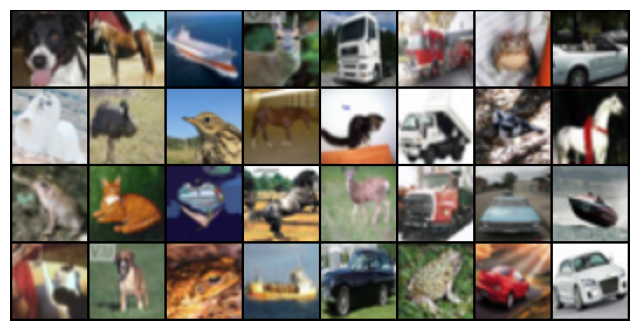

In [7]:


def denorm(x):
    """
    Undo the normalization: from [-1,1] back to [0,1]
    assuming mean=0.5, std=0.5.
    """
    return x * 0.5 + 0.5

def show_images(images, nrow=8):
    grid = utils.make_grid(denorm(images).clamp(0,1), nrow=nrow)
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()

# quick sanity check (one batch)
real_batch, _ = next(iter(train_loader))
print("Batch shape:", real_batch.shape)
show_images(real_batch[:32])


In [8]:


class Generator(nn.Module):
    def __init__(self, z_dim=128, base_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            # Input: Z -> (base_ch*8) x 4 x 4
            nn.ConvTranspose2d(z_dim, base_ch * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(True),

            # (base_ch*8) x 4 x 4 -> (base_ch*4) x 8 x 8
            nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(True),

            # (base_ch*4) x 8 x 8 -> (base_ch*2) x 16 x 16
            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(True),

            # (base_ch*2) x 16 x 16 -> (base_ch) x 32 x 32
            nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(True),

            # (base_ch) x 32 x 32 -> 3 x 64 x 64
            nn.ConvTranspose2d(base_ch, 3, 4, 2, 1, bias=False),
            nn.Tanh(),  # outputs in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


In [9]:

class Critic(nn.Module):
    def __init__(self, base_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            # 3 x 64 x 64 -> base_ch x 32 x 32
            nn.Conv2d(3, base_ch, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # base_ch x 32 x 32 -> base_ch*2 x 16 x 16
            nn.Conv2d(base_ch, base_ch * 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # base_ch*2 x 16 x 16 -> base_ch*4 x 8 x 8
            nn.Conv2d(base_ch * 2, base_ch * 4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # base_ch*4 x 8 x 8 -> base_ch*8 x 4 x 4
            nn.Conv2d(base_ch * 4, base_ch * 8, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # base_ch*8 x 4 x 4 -> 1 x 1 x 1
            nn.Conv2d(base_ch * 8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1)  # (batch,)


In [10]:


def weights_init_dcgan(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator(z_dim=latent_dim).to(device)
C = Critic().to(device)

G.apply(weights_init_dcgan)
C.apply(weights_init_dcgan)

# NOTE: separate learning rates
opt_G = optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, beta2))
opt_C = optim.Adam(C.parameters(), lr=lr_C, betas=(beta1, beta2))

print("Generator:")
print(G)
print("\nCritic:")
print(C)


Generator:
Generator(
  (net): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tan

In [11]:


def gradient_penalty(critic, real, fake, device, lambda_gp=10.0):
    """
    Gradient penalty on random interpolations between real and fake.
    """
    batch_size = real.size(0)

    eps = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = eps * real + (1 - eps) * fake
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    grad_outputs = torch.ones_like(mixed_scores, device=device)
    gradients = torch.autograd.grad(
        outputs=mixed_scores,
        inputs=interpolated,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1.0) ** 2).mean()
    return lambda_gp * gp


In [12]:


fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)


In [13]:


import numpy as np
from torchvision.models import inception_v3, Inception_V3_Weights
from scipy.linalg import sqrtm
import torch.nn.functional as F

# Load pretrained InceptionV3 using the new 'weights' argument
weights = Inception_V3_Weights.IMAGENET1K_V1
fid_model = inception_v3(weights=weights)  # no aux_logits / transform_input args
# Replace final FC with Identity so we get 2048-D features directly
fid_model.fc = nn.Identity()
fid_model = fid_model.to(device)
fid_model.eval()

def get_inception_activations(x, model, batch_size=64):
    """
    x: tensor in [0,1], shape (N, 3, H, W)
    returns: activations (N, D), here D=2048
    """
    model.eval()
    n = x.size(0)
    activations = []

    with torch.no_grad():
        for i in range(0, n, batch_size):
            batch = x[i:i+batch_size].to(device)
            # Inception expects 299x299
            batch = F.interpolate(batch, size=(299, 299), mode="bilinear", align_corners=False)
            preds = model(batch)  # (B, 2048) because we set fc = Identity
            activations.append(preds.detach().cpu())

    activations = torch.cat(activations, dim=0)
    return activations.numpy()

def calculate_fid(real, fake, model):
    """
    real, fake: tensors in [0,1] with shape (N, 3, H, W)
    model: Inception model
    returns: scalar FID estimate
    """
    real_np = get_inception_activations(real, model)
    fake_np = get_inception_activations(fake, model)

    mu_real = np.mean(real_np, axis=0)
    mu_fake = np.mean(fake_np, axis=0)
    cov_real = np.cov(real_np, rowvar=False)
    cov_fake = np.cov(fake_np, rowvar=False)

    diff = mu_real - mu_fake
    diff_sq = diff.dot(diff)

    covmean = sqrtm(cov_real.dot(cov_fake))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff_sq + np.trace(cov_real + cov_fake - 2 * covmean)
    return float(fid)


In [14]:


G_losses = []
C_losses = []
fid_scores = []   # FID per epoch

for epoch in range(1, num_epochs + 1):
    G.train()
    C.train()

    epoch_loss_G = 0.0
    epoch_loss_C = 0.0
    num_batches = 0

    print(f"\n=== Epoch {epoch}/{num_epochs} ===")
    for batch_idx, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        cur_batch_size = real_imgs.size(0)
        num_batches += 1

        # -----------------------
        #  Train Critic (fewer steps)
        # -----------------------
        for _ in range(n_critic):   # now n_critic = 1
            z = torch.randn(cur_batch_size, latent_dim, 1, 1, device=device)
            fake_imgs = G(z).detach()

            critic_real = C(real_imgs)
            critic_fake = C(fake_imgs)

            gp = gradient_penalty(C, real_imgs, fake_imgs, device, lambda_gp=lambda_gp)

            # WGAN critic loss
            loss_C = -(critic_real.mean() - critic_fake.mean()) + gp

            opt_C.zero_grad()
            loss_C.backward()
            opt_C.step()

        epoch_loss_C += loss_C.item()

        # -----------------------
        #  Train Generator (same frequency as critic now)
        # -----------------------
        z = torch.randn(cur_batch_size, latent_dim, 1, 1, device=device)
        fake_imgs = G(z)
        critic_fake = C(fake_imgs)

        loss_G = -critic_fake.mean()

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        epoch_loss_G += loss_G.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  [batch {batch_idx+1:4d}] "
                  f"C_loss: {loss_C.item():.3f} | G_loss: {loss_G.item():.3f}")

    # ---- average losses per epoch ----
    epoch_loss_C /= num_batches
    epoch_loss_G /= num_batches
    C_losses.append(epoch_loss_C)
    G_losses.append(epoch_loss_G)

    # ---- FID for this epoch (approx, single batch) ----
    G.eval()
    with torch.no_grad():
        real_batch, _ = next(iter(train_loader))
        real_batch = real_batch.to(device)

        z = torch.randn(real_batch.size(0), latent_dim, 1, 1, device=device)
        fake_batch = G(z)

        real_for_fid = denorm(real_batch).clamp(0, 1)
        fake_for_fid = denorm(fake_batch).clamp(0, 1)

        fid_value = calculate_fid(real_for_fid, fake_for_fid, fid_model)
        fid_scores.append(fid_value)

    print(f"Epoch [{epoch}/{num_epochs}] "
          f"C_loss: {epoch_loss_C:.4f} | G_loss: {epoch_loss_G:.4f} | FID: {fid_value:.2f}")

    # ---- Save sample grid for this epoch ----
    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()
    utils.save_image(
        fake,
        SAMPLE_DIR / f"epoch_{epoch:03d}.png",
        normalize=True,
    )

    # ---- Save checkpoints ----
    torch.save(G.state_dict(), CKPT_DIR / f"G_epoch_{epoch:03d}.pth")
    torch.save(C.state_dict(), CKPT_DIR / f"C_epoch_{epoch:03d}.pth")



=== Epoch 1/50 ===
  [batch  100] C_loss: 7.807 | G_loss: -7.193
  [batch  200] C_loss: 5.758 | G_loss: -10.105
  [batch  300] C_loss: 2.936 | G_loss: -2.489
Epoch [1/50] C_loss: 2.1643 | G_loss: -6.7772 | FID: 335.03

=== Epoch 2/50 ===
  [batch  100] C_loss: 2.881 | G_loss: -0.293
  [batch  200] C_loss: -0.582 | G_loss: -1.372
  [batch  300] C_loss: 0.552 | G_loss: 1.693
Epoch [2/50] C_loss: 2.4534 | G_loss: -0.2405 | FID: 294.53

=== Epoch 3/50 ===
  [batch  100] C_loss: 0.254 | G_loss: 2.136
  [batch  200] C_loss: 1.404 | G_loss: 0.964
  [batch  300] C_loss: 2.216 | G_loss: 0.598
Epoch [3/50] C_loss: 0.3554 | G_loss: 0.0048 | FID: 220.11

=== Epoch 4/50 ===
  [batch  100] C_loss: -0.126 | G_loss: 2.392
  [batch  200] C_loss: -0.283 | G_loss: 1.013
  [batch  300] C_loss: -0.386 | G_loss: -4.426
Epoch [4/50] C_loss: 0.0052 | G_loss: 0.3276 | FID: 207.78

=== Epoch 5/50 ===
  [batch  100] C_loss: -0.400 | G_loss: 1.059
  [batch  200] C_loss: 0.635 | G_loss: -0.815
  [batch  300] C_lo

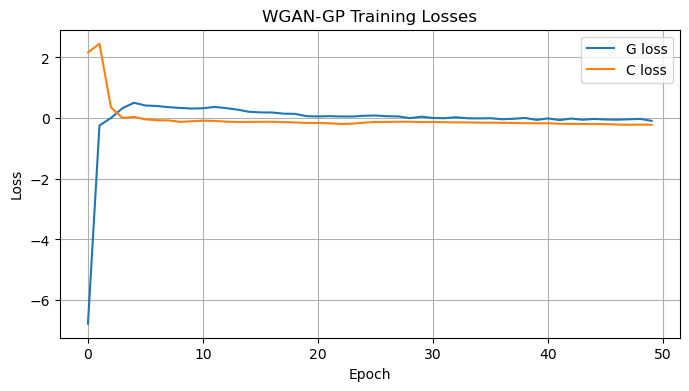

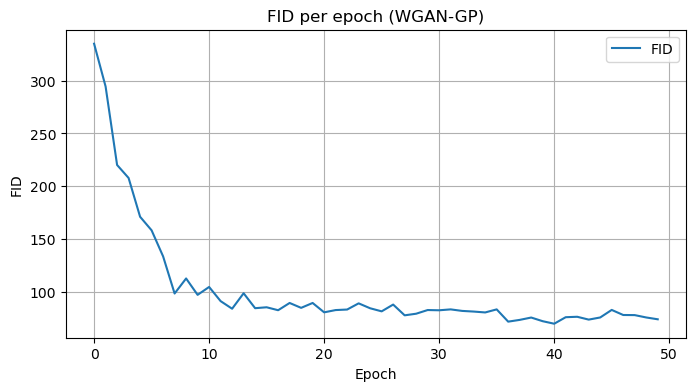

In [15]:


plt.figure(figsize=(8, 4))
plt.plot(G_losses, label="G loss")
plt.plot(C_losses, label="C loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("WGAN-GP Training Losses")
plt.grid(True)
plt.show()

# Optionally, also plot FID per epoch
plt.figure(figsize=(8, 4))
plt.plot(fid_scores, label="FID")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.legend()
plt.title("FID per epoch (WGAN-GP)")
plt.grid(True)
plt.show()


Best FID at epoch 41 with FID = 69.65


/local_scratch/slurm.7134955/ipykernel_549921/2387703126.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  G_best.load_state_dict(torch.load(best_ckpt_path, map_location=

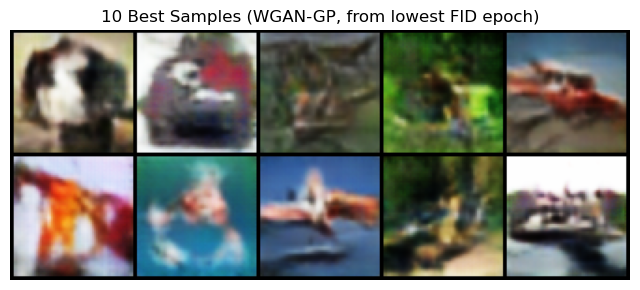

Average FID across all epochs (WGAN-GP): 101.84826909152227


In [16]:


# Find the epoch with the lowest FID
if len(fid_scores) > 0:
    best_epoch_idx = int(np.argmin(fid_scores))  # 0-based index
    best_epoch = best_epoch_idx + 1              # epochs are 1-based
    print(f"Best FID at epoch {best_epoch} with FID = {fid_scores[best_epoch_idx]:.2f}")

    # Load best generator checkpoint
    best_ckpt_path = CKPT_DIR / f"G_epoch_{best_epoch:03d}.pth"
    G_best = Generator(z_dim=latent_dim).to(device)
    G_best.load_state_dict(torch.load(best_ckpt_path, map_location=device))
    G_best.eval()

    # Generate 10 images from best model
    num_samples = 10
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim, 1, 1, device=device)
        best_samples = G_best(z).cpu()

    best_samples_denorm = denorm(best_samples).clamp(0, 1)

    # 2 x 5 grid
    grid = utils.make_grid(best_samples_denorm, nrow=5)

    plt.figure(figsize=(8, 4))
    plt.axis("off")
    plt.title("10 Best Samples (WGAN-GP, from lowest FID epoch)")
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.show()

    # Average FID across epochs
    avg_fid = float(np.mean(fid_scores))
    print("Average FID across all epochs (WGAN-GP):", avg_fid)
else:
    print("No FID scores recorded. Train the model first.")
